In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report

In [33]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [34]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [35]:
df_nueva_data = df[['v1', 'v2']]
df_nueva_data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [36]:
df_nueva_data = df_nueva_data.rename(
    columns = {
        'v1': 'categoria',
        'v2': 'descripcion'
    }
)

In [37]:
df_nueva_data.head(5)

,categoria,descripcion
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [38]:
X = df_nueva_data['descripcion']
y = df_nueva_data['categoria']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 19)

In [40]:
vectorizador = CountVectorizer()
X_train_vec = vectorizador.fit_transform(X_train)
X_test_vec = vectorizador.transform(X_test)

In [41]:
gaussian = GaussianNB()
gaussian.fit(X_train_vec.toarray(), y_train)

GaussianNB()

In [42]:
y_pred = gaussian.predict(X_test_vec.toarray())
print(y_pred)

['ham' 'spam' 'spam' ... 'spam' 'spam' 'ham']


In [43]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9061004784688995


In [44]:
f1 = f1_score(y_test, y_pred, pos_label = 'spam')
print(f1)

0.740495867768595


In [45]:
report = classification_report(y_test, y_pred, target_names=['spam', 'ham'])
print(report)

              precision    recall  f1-score   support

        spam       0.98      0.91      0.94      1425
         ham       0.63      0.91      0.74       247

    accuracy                           0.91      1672
   macro avg       0.80      0.91      0.84      1672
weighted avg       0.93      0.91      0.91      1672



In [46]:
# Importaciones para MultinomialNB y visualizaciones
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [47]:
# MULTINOMIAL NAIVE BAYES
print("=== MULTINOMIAL NAIVE BAYES ===")

# Crear y entrenar el modelo
modelo_multi = MultinomialNB()
modelo_multi.fit(X_train_vec, y_train)

# Predicciones
y_pred_multi = modelo_multi.predict(X_test_vec)

# Métricas
accuracy_multi = accuracy_score(y_test, y_pred_multi)
print(f"Accuracy MultinomialNB: {accuracy_multi:.4f}")

print("\n=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred_multi, target_names=['ham', 'spam']))

# Matriz de Confusión
cm_multi = confusion_matrix(y_test, y_pred_multi)
print("\nMatriz de Confusión:")
print(cm_multi)

=== MULTINOMIAL NAIVE BAYES ===
Accuracy MultinomialNB: 0.9856

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99      1425
        spam       0.97      0.93      0.95       247

    accuracy                           0.99      1672
   macro avg       0.98      0.96      0.97      1672
weighted avg       0.99      0.99      0.99      1672


Matriz de Confusión:
[[1418    7]
 [  17  230]]


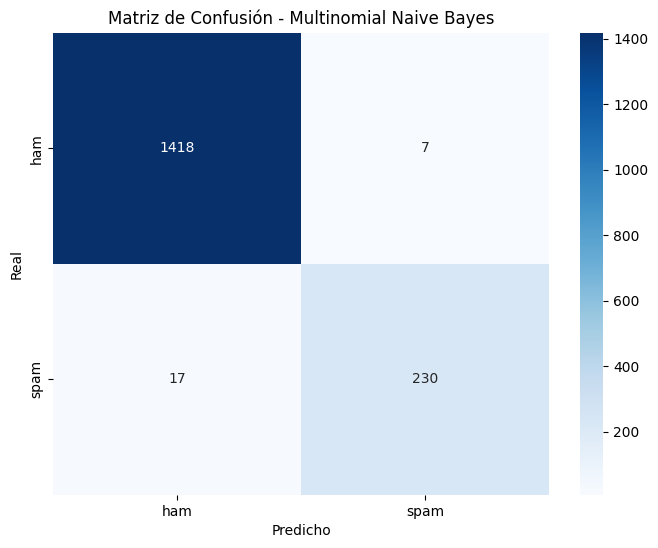

GaussianNB Accuracy : 0.9061
MultinomialNB Accuracy: 0.9856


In [48]:
# Visualización de Matriz de Confusión - MultinomialNB
plt.figure(figsize=(8, 6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'],
            yticklabels=['ham', 'spam'])
plt.title('Matriz de Confusión - Multinomial Naive Bayes')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Comparación con GaussianNB
print(f"GaussianNB Accuracy : {accuracy:.4f}")
print(f"MultinomialNB Accuracy: {accuracy_multi:.4f}")

In [49]:
#COMPARACIÓN Y ANÁLISIS

print("=== COMPARACIÓN FINAL DE MODELOS ===")
print(f"GaussianNB     → Accuracy: {accuracy:.4f}")
print(f"MultinomialNB  → Accuracy: {accuracy_multi:.4f}")

print("\n=== INTERPRETACIÓN ===")
print("""• MultinomialNB es mucho más adecuado para clasificación de texto (como spam).
• GaussianNB asume datos continuos y requiere .toarray(), lo que lo hace menos eficiente.
• MultinomialNB maneja directamente conteos de palabras (mejor rendimiento).
• El F1-score en la clase 'spam' suele mejorar notablemente con Multinomial.""")

# Tabla comparativa
comparacion = pd.DataFrame({
    'Modelo': ['GaussianNB', 'MultinomialNB'],
    'Accuracy': [accuracy, accuracy_multi],
    'F1-Score (spam)': [
        f1_score(y_test, y_pred, pos_label='spam'),
        f1_score(y_test, y_pred_multi, pos_label='spam')
    ]
})

display(comparacion.round(4))

=== COMPARACIÓN FINAL DE MODELOS ===
GaussianNB     → Accuracy: 0.9061
MultinomialNB  → Accuracy: 0.9856

=== INTERPRETACIÓN ===
• MultinomialNB es mucho más adecuado para clasificación de texto (como spam).
• GaussianNB asume datos continuos y requiere .toarray(), lo que lo hace menos eficiente.
• MultinomialNB maneja directamente conteos de palabras (mejor rendimiento).
• El F1-score en la clase 'spam' suele mejorar notablemente con Multinomial.


,Modelo,Accuracy,F1-Score (spam)
0,GaussianNB,0.9061,0.7405
1,MultinomialNB,0.9856,0.9504


In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Usando TF-IDF (mejor que solo conteos)
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

modelo_tfidf = MultinomialNB()
modelo_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = modelo_tfidf.predict(X_test_tfidf)

print(f"Accuracy MultinomialNB + TF-IDF: {accuracy_score(y_test, y_pred_tfidf):.4f}")
print(classification_report(y_test, y_pred_tfidf, target_names=['ham', 'spam']))

Accuracy MultinomialNB + TF-IDF: 0.9480
              precision    recall  f1-score   support

         ham       0.94      1.00      0.97      1425
        spam       1.00      0.65      0.79       247

    accuracy                           0.95      1672
   macro avg       0.97      0.82      0.88      1672
weighted avg       0.95      0.95      0.94      1672

